# Embedding Space Exploration (optional)

UMAP / clustering visualisation of the candidate pool. Purely diagnostic — not
part of the ranking.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from asr_poc.config import load_config
from asr_poc.io_utils import set_seed
cfg = load_config(ROOT / "config" / "target.yaml")
set_seed(cfg.run.seed)
cfg.paths.ensure_dirs()
print("Target:", cfg.target.name, "| embeddings:", cfg.embeddings.provider, "| report.top_n:", cfg.report.top_n)

Target: lipase | embeddings: local | report.top_n: 3


## UMAP of candidates + anchors

C:\Users\gcv\Downloads\AI_POC 2\AI_POC\project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\gcv\Downloads\AI_POC 2\AI_POC\project\.venv\Lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


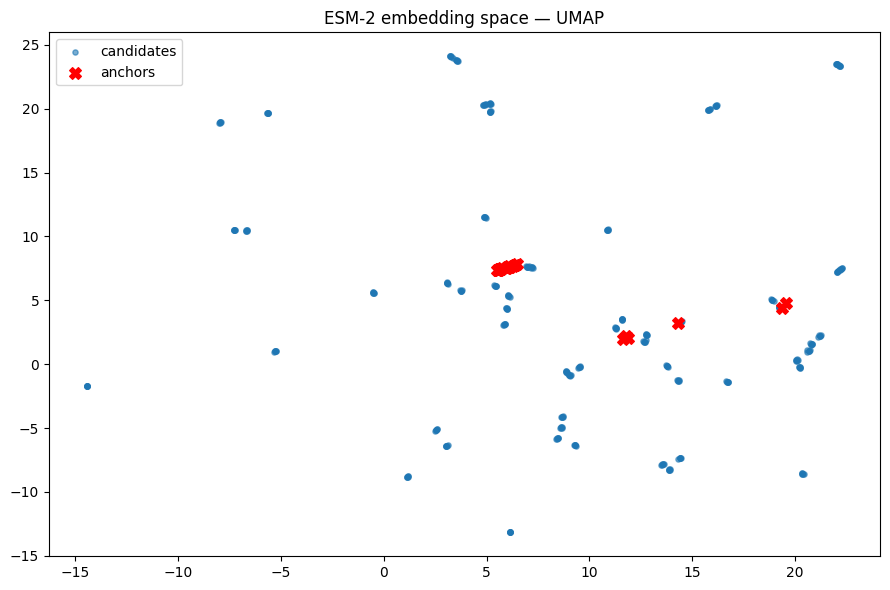

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import umap
from asr_poc import embeddings
cand = embeddings.load_embeddings(cfg.paths.candidate_embeddings)
anch = embeddings.load_embeddings(cfg.paths.anchor_embeddings)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
all_v = reducer.fit_transform(pd.concat([cand, anch]).values)
plt.figure(figsize=(9,6))
plt.scatter(all_v[:len(cand),0], all_v[:len(cand),1], s=14, alpha=0.6, label="candidates")
plt.scatter(all_v[len(cand):,0], all_v[len(cand):,1], c="red", marker="X", s=70, label="anchors")
plt.title("ESM-2 embedding space — UMAP"); plt.legend(); plt.tight_layout(); plt.show()